In [4]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# DATASET: CREDIT RISK PREDICTION
df=pd.read_csv("raw_dataset.csv")
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [6]:
#EDA
df.shape

(100000, 28)

In [7]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [9]:
df.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

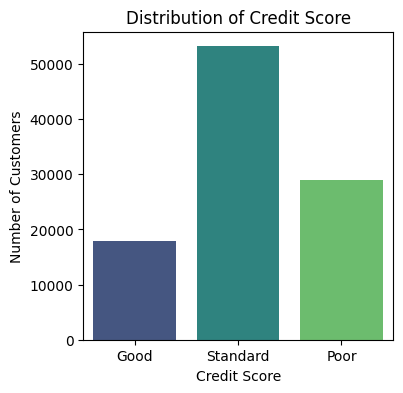

In [11]:
plt.figure(figsize=(4,4))

sns.countplot(
    x='Credit_Score',
    data=df,
    palette='viridis'
)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.show()

In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


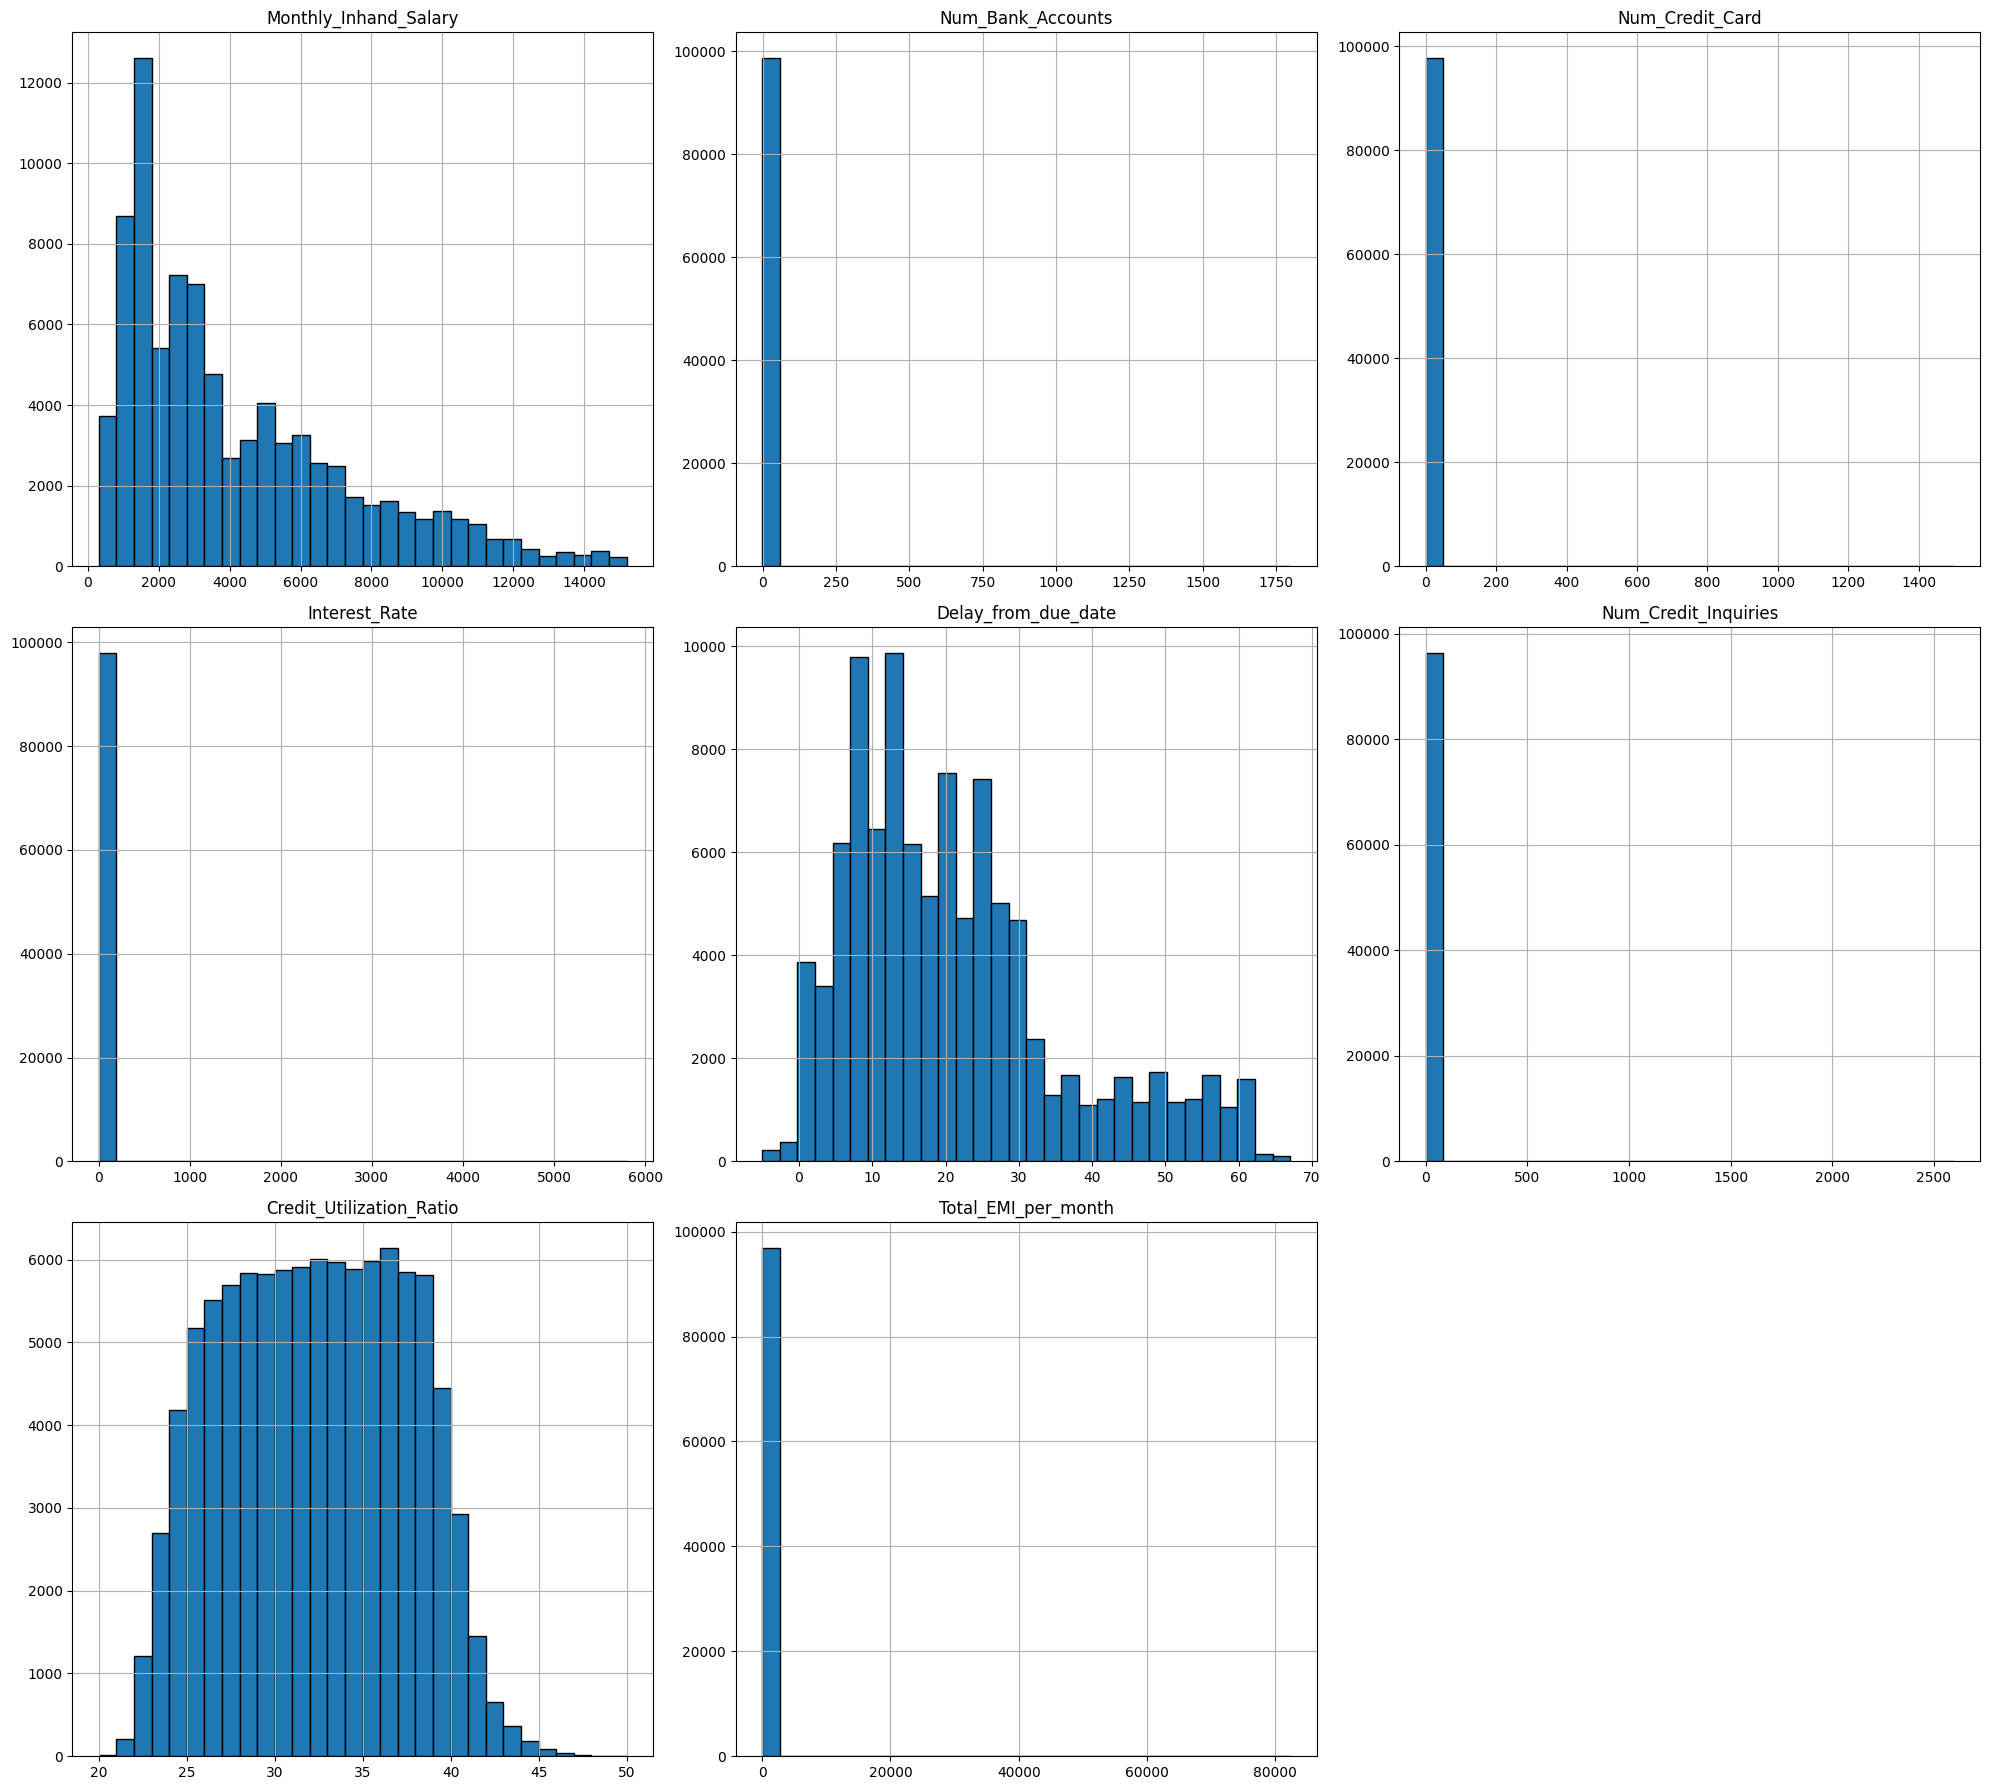

In [13]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols].hist(
    figsize=(20,18),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

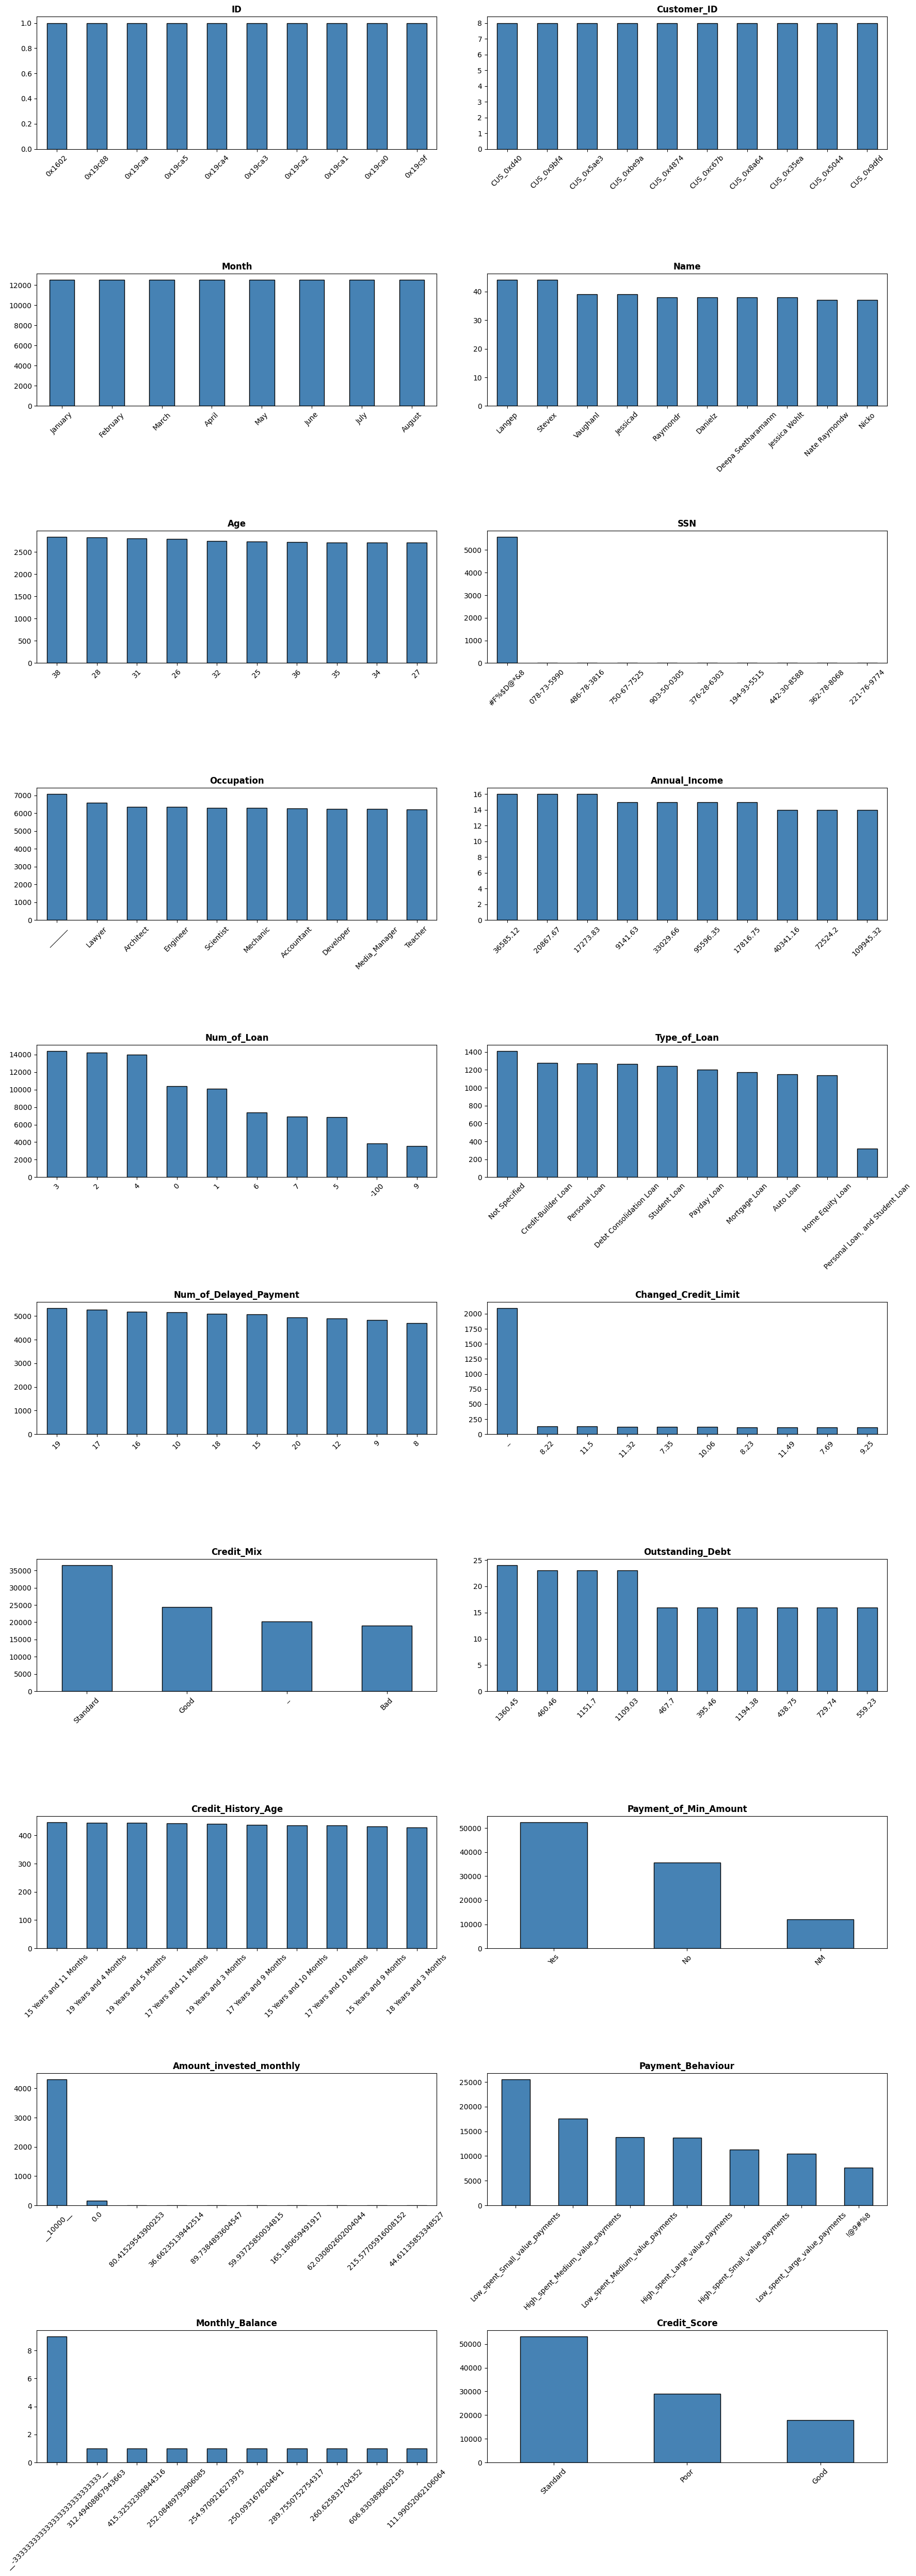

In [19]:
categorical_cols = df.select_dtypes(include='object').columns
rows = (len(categorical_cols) + 1) // 2
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().head(10).plot(
        kind='bar',
        ax=axes[i],
        color='steelblue',
        edgecolor='black')

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

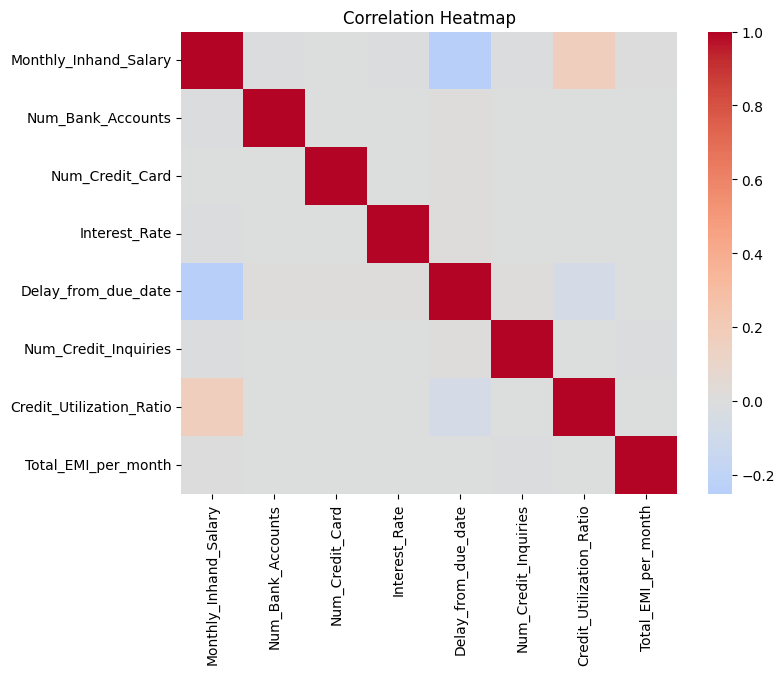

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [36]:
#Preprocessing
#1.Handling null values
df["Name"]=df["Name"].fillna("Unknown")
df["Type_of_Loan"]=df["Type_of_Loan"].fillna("Not Specified")
df["Monthly_Inhand_Salary"].median()   #median is lesser than mean means that the column is right skewed
df["Monthly_Inhand_Salary"]=df["Monthly_Inhand_Salary"].fillna(df["Monthly_Inhand_Salary"].median())
df["Num_Credit_Inquiries"]=df["Num_Credit_Inquiries"].fillna(df["Num_Credit_Inquiries"].median())
df['Num_of_Delayed_Payment'] =df['Num_of_Delayed_Payment'].str.extract(r'(\d+)')
df['Num_of_Delayed_Payment']=pd.to_numeric(df['Num_of_Delayed_Payment'],errors="coerce")
df['Num_of_Delayed_Payment']=df['Num_of_Delayed_Payment'].fillna(df['Num_of_Delayed_Payment'].median())

In [37]:
df['Credit_History_Age'] = df['Credit_History_Age'].replace('NA', pd.NA)
df[['years', 'months']] = df['Credit_History_Age'].str.extract(
    r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?')

df[['years', 'months']]=df[['years', 'months']].fillna(0)
df['Credit_History_Years'] = ( df['years'].astype(int) + df['months'].astype(int)/12 ).round(2)
column=['years','months','Credit_History_Age']
df=df.drop(column,axis=1)

In [38]:
df['Amount_invested_monthly'] =df['Amount_invested_monthly'].str.extract(r'(\d+\.?\d*)')
df['Amount_invested_monthly']=pd.to_numeric(df['Amount_invested_monthly'],errors="coerce")
df['Amount_invested_monthly']=df['Amount_invested_monthly'].fillna(df['Amount_invested_monthly'].median())


In [39]:
df['Monthly_Balance'] = df['Monthly_Balance'].replace(
    '-333333333333333333333333333',np.nan)
df['Monthly_Balance'] = df['Monthly_Balance'].str.extract(r'(\d+\.?\d*)')
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'],errors="coerce")
df.loc[df['Monthly_Balance'] > 100000, 'Monthly_Balance'] = np.nan
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(df['Monthly_Balance'].median())

In [40]:
df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Credit_History_Years        0
dtype: int64

In [41]:
#2.Handling noises 
#Invalid placeholder values in the Occupation feature were replaced with the category 'Unknown' to preserve records while explicitly representing missing occupational information.
df["Occupation"].unique()
df["Occupation"]=df["Occupation"].replace('_______',"Unknown")
df["Age"]=df["Age"].str.extract(r'(\d+)')
df["Age"]=df["Age"].astype(int)
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median())
df["Annual_Income"]=df["Annual_Income"].str.extract(r'(\d+)')
df["Annual_Income"]=df["Annual_Income"].astype(int)
df["Num_of_Loan"]=df["Num_of_Loan"].str.extract(r'(\d+)')
df["Num_of_Loan"]=df["Num_of_Loan"].astype(int)
df["Outstanding_Debt"]=df["Outstanding_Debt"].str.extract(r'(\d+)')
df["Outstanding_Debt"]=df["Outstanding_Debt"].astype(int)

In [42]:
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('_', np.nan)
df['Changed_Credit_Limit'] = pd.to_numeric(
    df['Changed_Credit_Limit'], errors='coerce')

df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].fillna(
    df['Changed_Credit_Limit'].median())

In [43]:
df['Credit_Mix'] = df['Credit_Mix'].replace('_', 'Unknown')
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', 'Unknown')

In [44]:
cols_to_drop = ['ID','Customer_ID','Name','SSN', 'Month']
df.drop(columns=cols_to_drop, inplace=True)

In [45]:
df['Payment_Behaviour'].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments', 'Unknown',
       'High_spent_Large_value_payments'], dtype=object)

In [46]:
df['Credit_Score'] = df['Credit_Score'].str.strip()
df['Credit_Score'] = df['Credit_Score'].map({
    'Poor': 0,
    'Standard': 1,
    'Good': 2
})
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({
    'No':0,
    'Yes':1,
    'NM':-1
})
df['Credit_Mix'] = df['Credit_Mix'].str.strip()
df['Credit_Mix'] = df['Credit_Mix'].map({
    'Bad': 0,
    'Standard': 1,
    'Good': 2,
    'Unknown': -1
})


In [47]:
df['Spending_Level'] = df['Payment_Behaviour'].apply(
    lambda x: x.split('_spent_')[0]
    if x != 'Unknown' else 'Unknown')
df['Payment_Size'] = df['Payment_Behaviour'].apply(
    lambda x: x.split('_spent_')[1]
    if x != 'Unknown' else 'Unknown')
df.drop('Payment_Behaviour', axis=1, inplace=True)

In [48]:
df = pd.get_dummies(df,
    columns=['Spending_Level', 'Payment_Size','Occupation'],
    drop_first=True,dtype=int)


In [49]:

df['Type_of_Loan'] = df['Type_of_Loan'].str.replace(
    r'\band\b','',regex=True)
df['Type_of_Loan'] = df['Type_of_Loan'].str.strip()
loan_lists = (
    df['Type_of_Loan']
    .fillna('')
    .apply(lambda x: [i.strip() for i in str(x).split(',') if i.strip()])
)
mlb = MultiLabelBinarizer()
loan_df = pd.DataFrame(
    mlb.fit_transform(loan_lists),
    columns=mlb.classes_,
    index=df.index)
df = pd.concat([df.drop('Type_of_Loan', axis=1), loan_df], axis=1)

In [50]:
df.isnull().sum()

Age                                   0
Annual_Income                         0
Monthly_Inhand_Salary                 0
Num_Bank_Accounts                     0
Num_Credit_Card                       0
Interest_Rate                         0
Num_of_Loan                           0
Delay_from_due_date                   0
Num_of_Delayed_Payment                0
Changed_Credit_Limit                  0
Num_Credit_Inquiries                  0
Credit_Mix                            0
Outstanding_Debt                      0
Credit_Utilization_Ratio              0
Payment_of_Min_Amount                 0
Total_EMI_per_month                   0
Amount_invested_monthly               0
Monthly_Balance                       0
Credit_Score                          0
Credit_History_Years                  0
Spending_Level_Low                    0
Spending_Level_Unknown                0
Payment_Size_Medium_value_payments    0
Payment_Size_Small_value_payments     0
Payment_Size_Unknown                  0


In [51]:
df.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_Score', 'Credit_History_Years', 'Spending_Level_Low',
       'Spending_Level_Unknown', 'Payment_Size_Medium_value_payments',
       'Payment_Size_Small_value_payments', 'Payment_Size_Unknown',
       'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor',
       'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Unknown', 'Occu

In [52]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,33.314300,1.062838e+01,14.000000,25.000000,33.000000,41.000000,1.000000e+02
Annual_Income,100000.0,176415.208820,1.429618e+06,7005.000000,19457.000000,37578.000000,72790.000000,2.419806e+07
Monthly_Inhand_Salary,100000.0,4029.084964,2.961364e+03,303.645417,1792.084167,3093.745000,5371.525000,1.520463e+04
Num_Bank_Accounts,100000.0,17.091280,1.174048e+02,-1.000000,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,22.474430,1.290574e+02,0.000000,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,72.466040,4.664226e+02,1.000000,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,10.761960,6.178993e+01,0.000000,2.000000,3.000000,6.000000,1.496000e+03
Delay_from_due_date,100000.0,21.068780,1.486010e+01,-5.000000,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,100000.0,29.759690,2.180147e+02,0.000000,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,100000.0,10.368345,6.719627e+00,-6.490000,5.420000,9.400000,14.660000,3.697000e+01


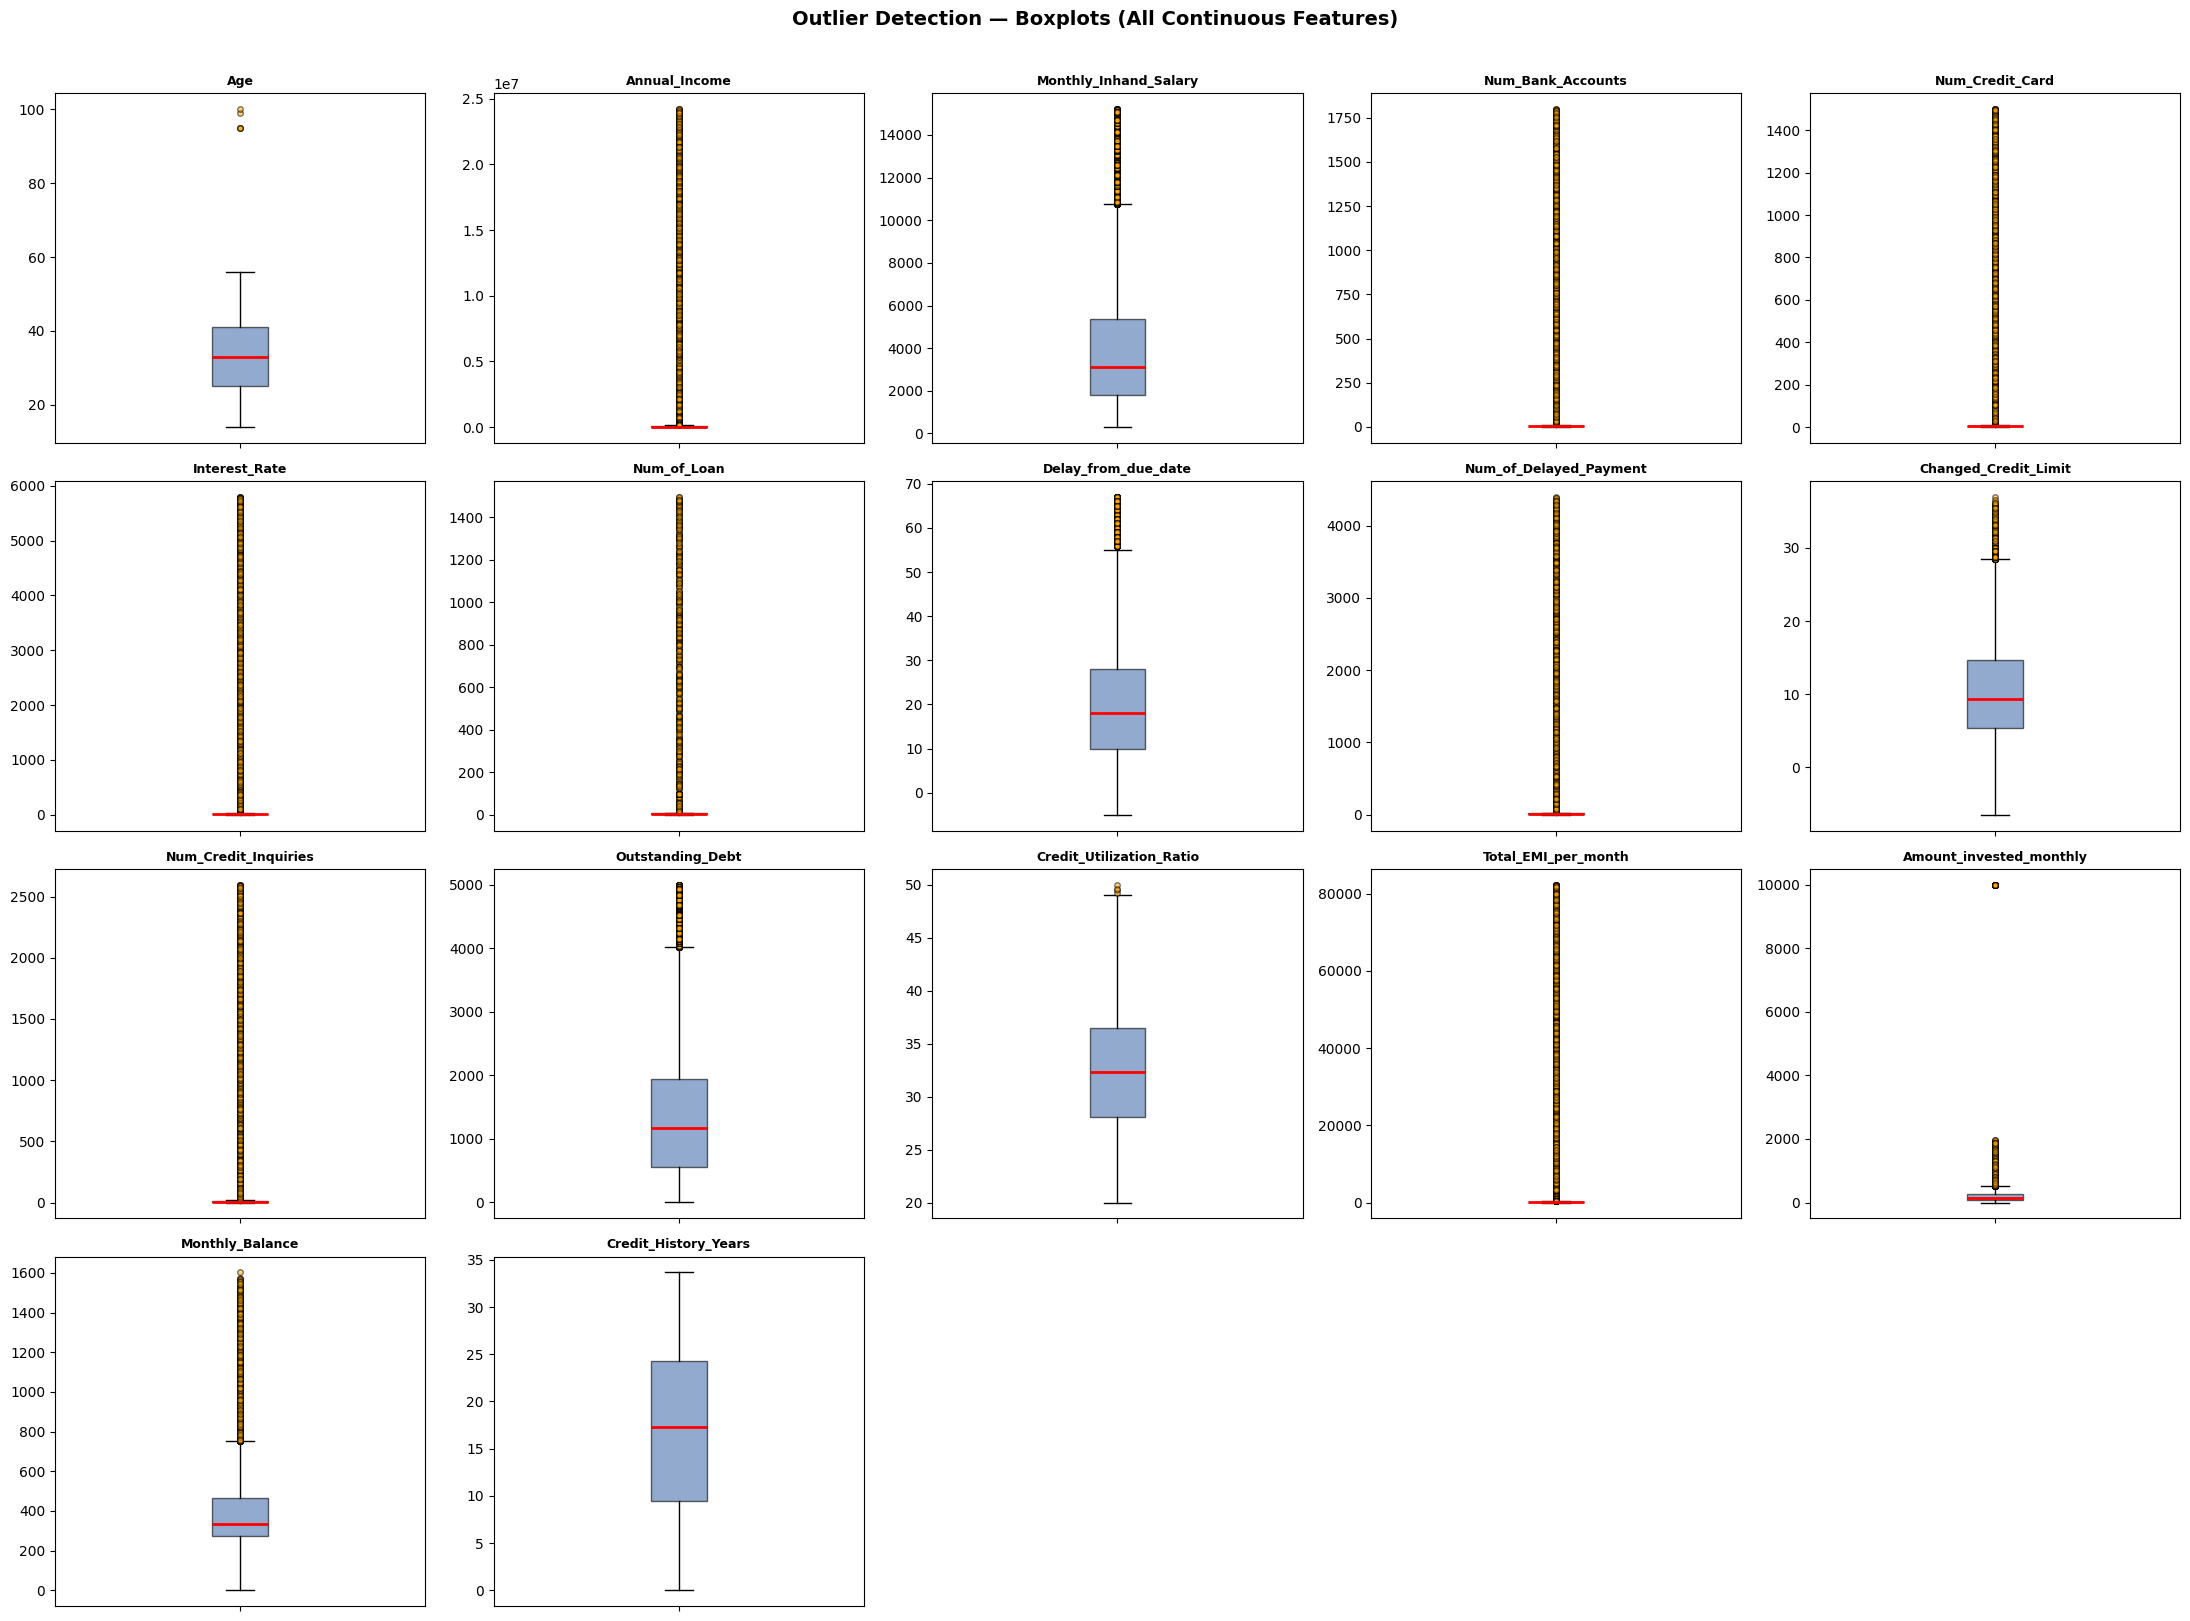

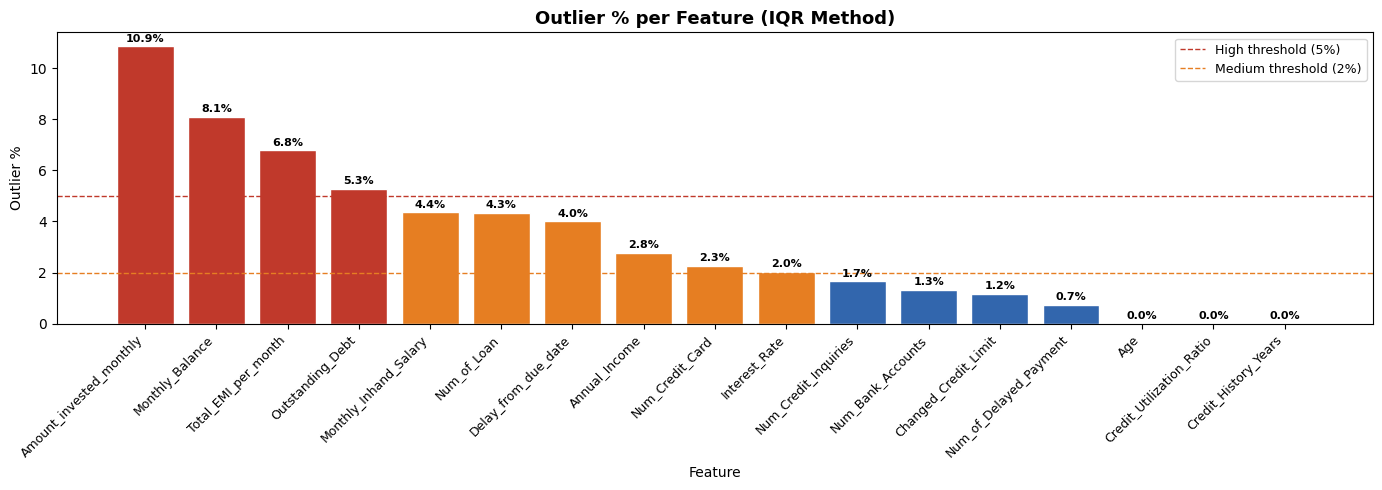

                 Feature       Q1       Q3      IQR  Lower fence  Upper fence  Outlier count  Outlier %
 Amount_invested_monthly    77.02   255.04   178.02      -190.01       522.07          10866      10.87
         Monthly_Balance   271.84   463.50   191.66       -15.65       751.00           8094       8.09
     Total_EMI_per_month    30.31   161.22   130.92      -166.07       357.60           6795       6.80
        Outstanding_Debt   566.00  1945.25  1379.25     -1502.88      4014.12           5272       5.27
   Monthly_Inhand_Salary  1792.08  5371.53  3579.44     -3577.08     10740.69           4365       4.36
             Num_of_Loan     2.00     6.00     4.00        -4.00        12.00           4348       4.35
     Delay_from_due_date    10.00    28.00    18.00       -17.00        55.00           4002       4.00
           Annual_Income 19457.00 72790.00 53333.00    -60542.50    152789.50           2783       2.78
         Num_Credit_Card     4.00     7.00     3.00        -0.50

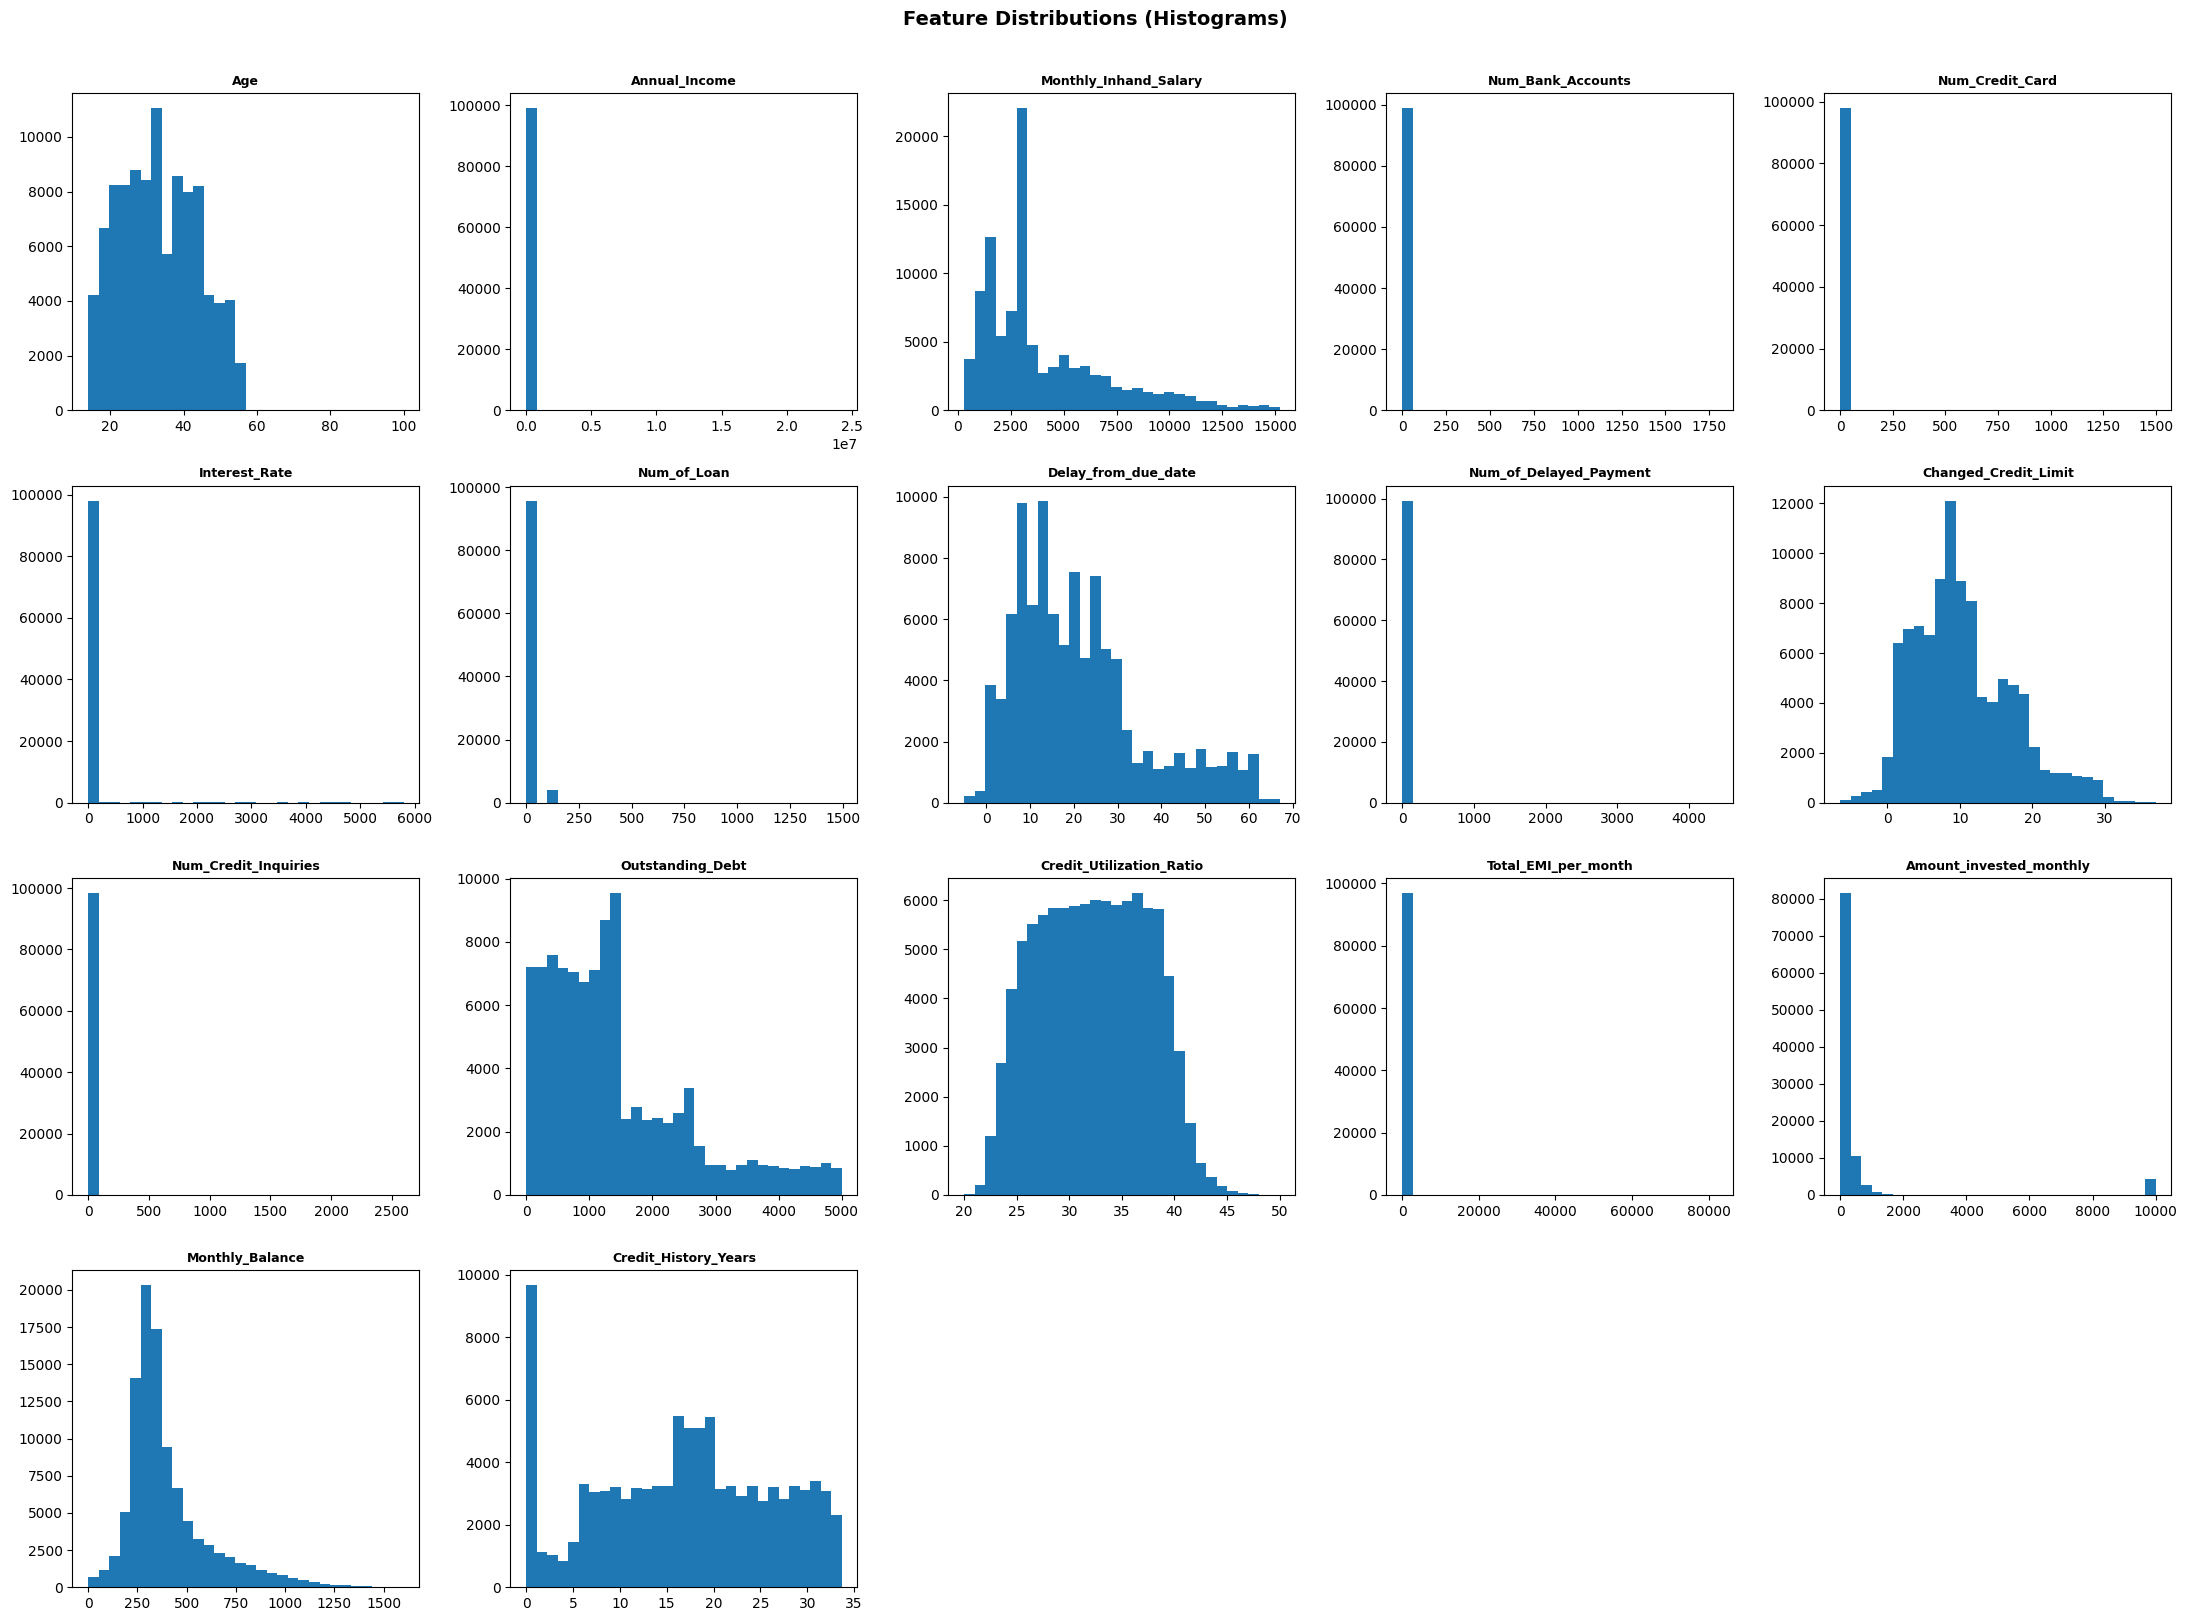

In [53]:

# Only continuous numeric columns — skip binary dummies
numeric_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Years'
]

# Plot 1: Boxplot Grid
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange',
                                    markerfacecolor='orange', markersize=4, alpha=0.5))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — Boxplots (All Continuous Features)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

#Plot 2: Outlier Count Bar Chart 
def iqr_outlier_count(col):
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    return ((col < Q1 - 1.5*IQR) | (col > Q3 + 1.5*IQR)).sum()

outlier_counts = pd.Series({c: iqr_outlier_count(df[c]) for c in numeric_cols})
outlier_pct    = (outlier_counts / len(df) * 100).sort_values(ascending=False)

colors = ['#c0392b' if p > 5 else '#e67e22' if p > 2 else '#3266ad'
          for p in outlier_pct.values]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(outlier_pct.index, outlier_pct.values, color=colors, edgecolor='white')

for bar, val in zip(bars, outlier_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(5, color='#c0392b', linestyle='--', linewidth=1, label='High threshold (5%)')
ax.axhline(2, color='#e67e22', linestyle='--', linewidth=1, label='Medium threshold (2%)')
ax.set_title('Outlier % per Feature (IQR Method)', fontsize=13, fontweight='bold')
ax.set_ylabel('Outlier %')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outlier_counts.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: IQR Bounds Summary Table 
summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = iqr_outlier_count(df[col])
    summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower fence': round(Q1 - 1.5*IQR, 2),
        'Upper fence': round(Q3 + 1.5*IQR, 2),
        'Outlier count': n_out,
        'Outlier %': round(n_out/len(df)*100, 2)
    })

summary_df = pd.DataFrame(summary).sort_values('Outlier %', ascending=False)
print(summary_df.to_string(index=False))

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9, fontweight='bold')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Feature Distributions (Histograms)',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

In [54]:
# IQR Clipping — use this for your top outlier columns
high_outlier_cols = [
    'Amount_invested_monthly', 'Monthly_Balance', 'Total_EMI_per_month',
    'Outstanding_Debt', 'Monthly_Inhand_Salary', 'Num_of_Loan',
    'Delay_from_due_date', 'Annual_Income'
]

for col in high_outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers handled via IQR clipping")
print(df.shape)

Outliers handled via IQR clipping ✅
(100000, 49)


In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,33.314300,10.628376,14.000000,25.000000,33.000000,41.000000,100.000000
Annual_Income,100000.0,51252.733625,38684.831624,7005.000000,19457.000000,37578.000000,72790.000000,152789.500000
Monthly_Inhand_Salary,100000.0,3956.893924,2757.643861,303.645417,1792.084167,3093.745000,5371.525000,10740.686250
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Num_of_Loan,100000.0,3.901870,2.951262,0.000000,2.000000,3.000000,6.000000,12.000000
Delay_from_due_date,100000.0,20.896640,14.427226,-5.000000,10.000000,18.000000,28.000000,55.000000
Num_of_Delayed_Payment,100000.0,29.759690,218.014703,0.000000,9.000000,14.000000,18.000000,4397.000000
Changed_Credit_Limit,100000.0,10.368345,6.719627,-6.490000,5.420000,9.400000,14.660000,36.970000


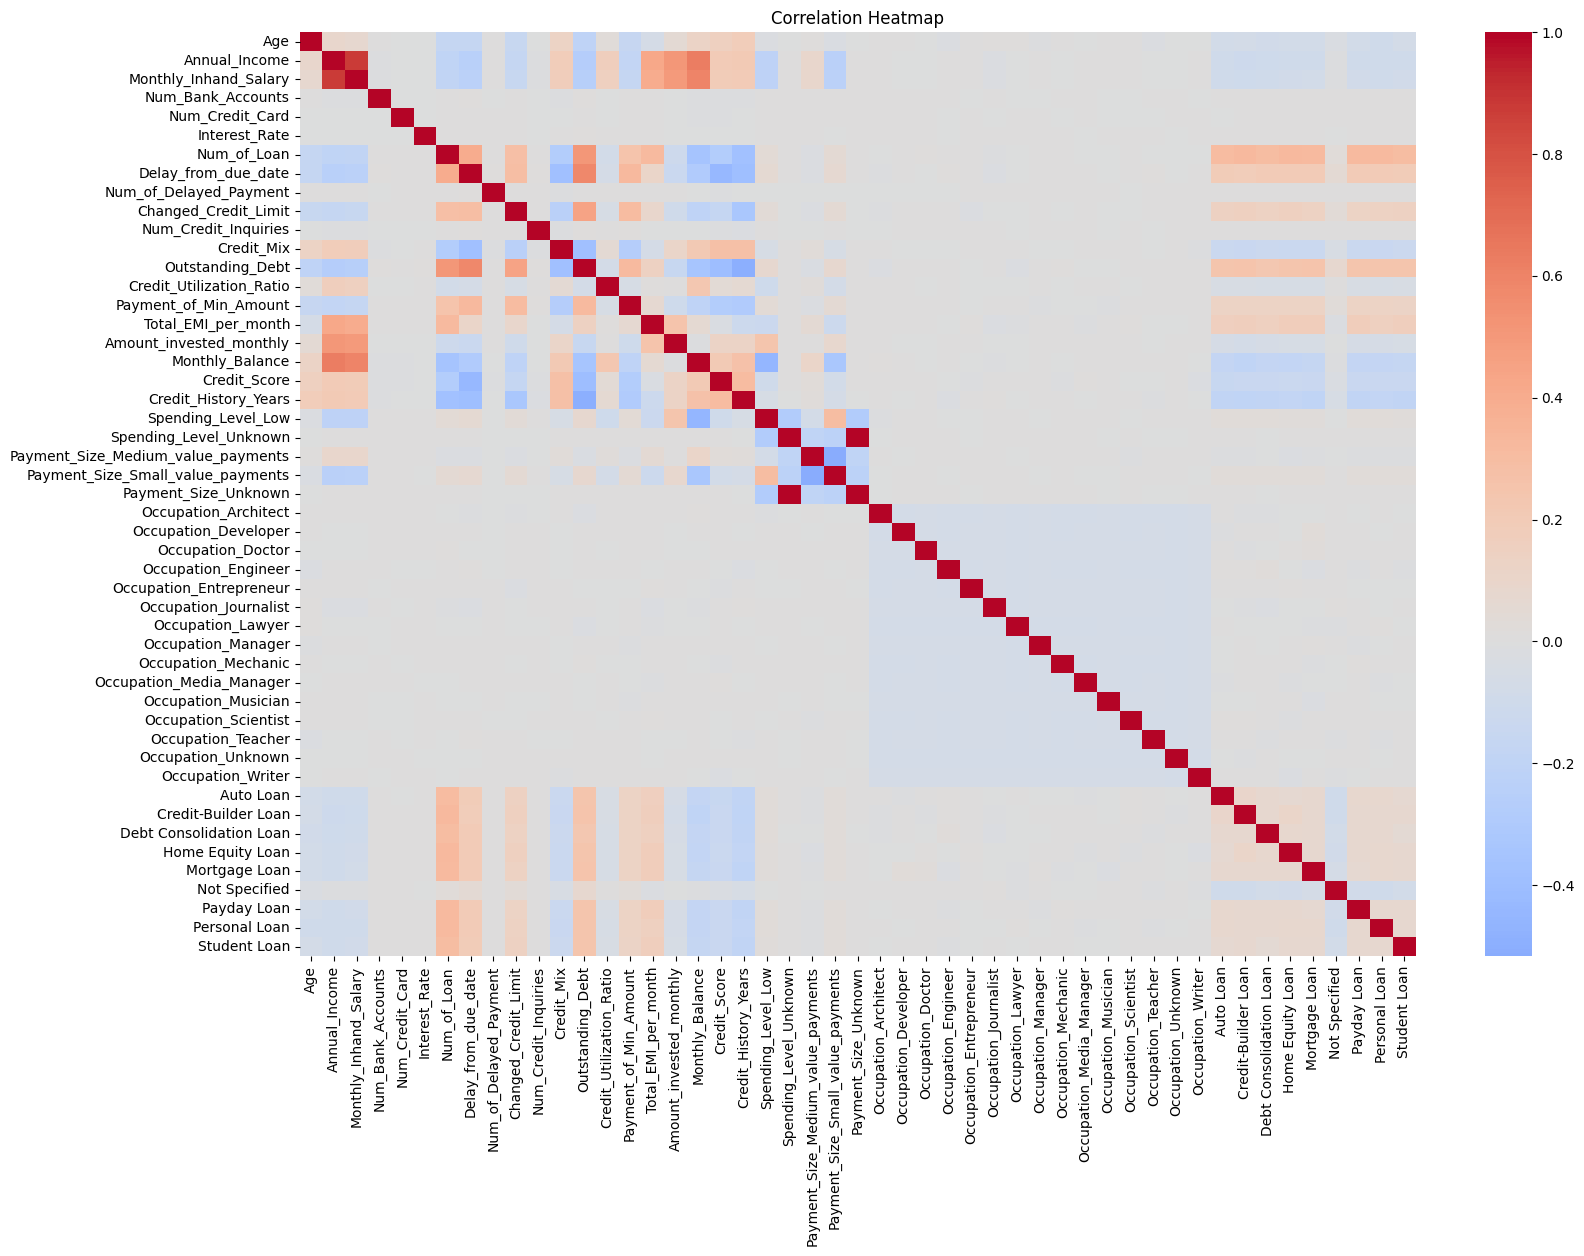

In [56]:
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(),cmap='coolwarm',center=0)

plt.title('Correlation Heatmap')
plt.show()

In [57]:
corr_target = (df.corr()['Credit_Score'].sort_values(ascending=False))

print(corr_target.head(15))
print(corr_target.tail(15))

Credit_Score                          1.000000
Credit_History_Years                  0.308741
Credit_Mix                            0.276147
Monthly_Balance                       0.209744
Annual_Income                         0.204831
Monthly_Inhand_Salary                 0.190301
Age                                   0.157543
Amount_invested_monthly               0.118470
Credit_Utilization_Ratio              0.045793
Payment_Size_Medium_value_payments    0.027558
Occupation_Media_Manager              0.012997
Occupation_Journalist                 0.007912
Occupation_Architect                  0.007277
Occupation_Musician                   0.006297
Occupation_Doctor                     0.006252
Name: Credit_Score, dtype: float64
Payment_Size_Small_value_payments   -0.083196
Spending_Level_Low                  -0.090932
Home Equity Loan                    -0.136328
Student Loan                        -0.139390
Debt Consolidation Loan             -0.140383
Mortgage Loan                 

In [58]:
df['Debt_to_Income'] = (
    df['Outstanding_Debt'] /
    (df['Annual_Income'] + 1))
df['EMI_to_Salary'] = (
    df['Total_EMI_per_month'] /
    (df['Monthly_Inhand_Salary'] + 1))
df['Loans_per_History'] = (
    df['Num_of_Loan'] /
    (df['Credit_History_Years'] + 1))

In [59]:
df[['Debt_to_Income',
    'EMI_to_Salary',
    'Loans_per_History',
    'Credit_Score']].corr()['Credit_Score']

Debt_to_Income      -0.307941
EMI_to_Salary       -0.135212
Loans_per_History   -0.136405
Credit_Score         1.000000
Name: Credit_Score, dtype: float64

In [60]:
df[['Debt_to_Income',
    'EMI_to_Salary',
    'Loans_per_History']].describe()

,Debt_to_Income,EMI_to_Salary,Loans_per_History
count,100000.000000,100000.000000,100000.000000
mean,0.058777,0.033096,0.674051
std,0.082997,0.039560,1.451302
min,0.000000,0.000000,0.000000
25%,0.009412,0.012144,0.077912
50%,0.027770,0.024998,0.180424
75%,0.067888,0.042654,0.554785
max,0.572383,1.173826,12.000000


In [61]:
df.to_csv("Credit_dataset.csv", index=False)